In [148]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [149]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [150]:
#PLOTTING
###########################################

In [151]:
#NEEDED TO PLOT THE CORRECT DATA
data_type="Tracked_Properties_Histogram"

In [164]:
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"tracked_profiles_{res}_{t_res}_{Np_str}.h5"
bin_arrays = {}
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        bin_arrays[key] = h5f[key][:]
        # print(key)

In [173]:
#CLIPPING SOME VARIABLES (IF PLOT IS TOO UNIFORM)
type2s=['CL','nonCL','SBZ','nonSBZ','ColdPool']
clip_keys=[]
for type2 in type2s:
    clip_keys+=[f"{type2}_ALL_profile_array_QCQI"]

for key in clip_keys:
    bin_arrays[key]= np.clip(bin_arrays[key], None, 1e4)

In [154]:
# #BASIC PLOT (MORE ADVANCED PLOT BELOW)

# def plot_profiles(bin_arrays,plot_type):
#     # Filter keys based on plot_type
#     selected_profiles = {name: data for name, data in bin_arrays.items()
#                           if name.startswith('CL_'+plot_type)}
    
#     nplots = len(selected_profiles)
#     if nplots == 0:
#         print(f"No profiles found for type '{plot_type}'")
#         return
    
#     ncols = 3
#     nrows = int(np.ceil(nplots / ncols))
    
#     fig = plt.figure(figsize=(5*ncols, 4*nrows))
#     gs = gridspec.GridSpec(nrows, ncols, figure=fig)
    
#     for idx, (name, data) in enumerate(selected_profiles.items()):
#         ax = fig.add_subplot(gs[idx])
#         pcm = ax.pcolor(data, shading='auto')
#         fig.colorbar(pcm, ax=ax)
#         ax.set_title(name, fontsize=10)
#         ax.set_xlabel('bins')
#         ax.set_ylabel('z index')
    
#     plt.tight_layout()
#     plt.show()

# plot_profiles(bin_arrays, plot_type='ALL')


In [155]:
def histogram2d_colors():
    colors_rgb = [
        [44, 87, 169],    # Blue 1
        [54, 92, 171],    # Blue 2
        [66, 97, 175],    # Blue 3
        [67, 107, 182],   # Blue 4
        [70, 117, 187],   # Blue 5
        [70, 125, 193],   # Blue 6
        [74, 140, 204],   # Blue 7
        [76, 157, 216],   # Blue 8
        [75, 178, 232],   # Blue 9
        [78, 192, 242],   # Blue 10
        [110, 201, 242],   # Blue 11
        [140, 207, 240],   # Blue 12
        [161, 219, 245],   # Blue 13
        [190, 226, 226],   # Blue 14
    
        [40, 150, 40],    # Green 1
        [60, 160, 60],    # Green 2
        [80, 180, 80],    # Green 3
        [120, 200, 120],  # Green 4
        
        # [225, 237, 178],   # Yellow 1
        [244, 239, 125],   # Yellow 2
        [247, 232, 75],   # Yellow 3
        [249, 213, 43],   # Yellow 4
        [247, 194, 14],   # Orange 1
        [245, 178, 15],   # Orange 2
        [242, 159, 19],   # Orange 4
        [238, 141, 22],   # Orange 5
        [236, 121, 26],   # Orange 6
        
        [230, 77, 34],   # Red 1
        [229, 51, 35],   # Red 2
        [228, 37, 30],   # Red 3
        [220, 29, 32],   # Red 4
        [205, 28, 32],   # Red 5
        
    ]
    colors = [[c / 255 for c in color] for color in colors_rgb]
    
    # #TESTING
    # custom_cmap = mcolors.ListedColormap(colors)
    
    # # Create an array to display the colorbar
    # data = np.linspace(0, 1, len(colors)).reshape(1, -1)
    
    # # Plotting the colorbar
    # fig, ax = plt.subplots(figsize=(10, 2))
    # cbar = ax.imshow(data, cmap=custom_cmap, aspect='auto')
    # ax.set_axis_off() 
    return colors

In [156]:
#HISTOGRAM BIN SETTINGS
####################################
def GetBinSettings(var_name):    

    pre_calculated=False
    pre_calculated=True

    if pre_calculated==False:
        bin_settings = {
            'W':        (W.min(), W.max(), 1000),
            'QV':       (QV.min(), QV.max(), 1000),
            'QCQI':     (QCQI.min(), QCQI.max(), 1000),
            'TH':       (TH.min(), TH.max(), 5000),
            'TH_E':     (TH_E.min(), TH.max(), 5000),
            'BUOYANCY': (BUOYANCY.min(), BUOYANCY.max(), 1000),
            'HMC':      (HMC.min(), HMC.max(), 1000),
        }
    elif pre_calculated==True:
        bin_settings = {
            'W': (-18.99606, 47.273865, 1000),
            'QV': (9.235839e-07, 0.022054985, 1000),
            'QCQI': (0.0, 0.0061959606, 1000),
            'TH': (297.87912, 463.44125, 5000),
            'TH_E': (324.8358, 463.43524, 5000),
            'BUOYANCY': (-0.78747416, 0.599328, 1000),
            'HMC': (-0.00031354488, 0.0001856628, 1000)
        }

    
    # Select bin range based on var_name
    if var_name is not None and var_name in bin_settings:
        bin_left, bin_right, num_bins = bin_settings[var_name]
    else:
        # fallback default
        bin_left, bin_right, num_bins = -50, 50, 1000
    return bin_left,bin_right,num_bins

In [165]:
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm

def HistogramPlot(axis,var_name,bin_array,number_xbins,num_contour_levels,add_grid,ylim,xlim,zero_line,meters,units,round_deg):

    #INITIALIZE COLORBAR
    ################
    # Define the colormap (white for 0, then the rest of the colors)
    colors = histogram2d_colors()  # White for 0, then the other colors
    custom_cmap = mcolors.ListedColormap(colors)
    custom_cmap.set_under("white")

    # Define contour levels, ensuring 0 is treated as a separate level
    num_levels = num_contour_levels
    levels = np.linspace(np.min(bin_array), np.max(bin_array), num_levels)
    # Create a norm that ensures correct color mapping for the levels
    norm = BoundaryNorm(levels, len(colors))
    
    #PLOTTING
    ##########
    # Ensure that 0 is included as the first level in the contour levels
    if 0 not in levels:
        levels = np.insert(levels, 0, 0)  # Insert 0 explicitly at the beginning
    
    # Plot using contourf with correct normalization
    im = axis.contourf(bin_array, levels=levels, cmap=custom_cmap, norm=norm, extend='min')
    
    #ADD A COLORBAR
    ################    
    cbar = plt.colorbar(im, ax=axis, orientation='vertical', fraction=0.05, pad=0.04, shrink=0.8, label='cumulative count', extend="min")
    # Set colorbar ticks based on the contour levels
    levels=levels[::2] #*** can add to function handle later
    cbar.set_ticks(levels)
    cbar.set_ticklabels(np.round(levels, 2))

    #SET AXIS LABELS
    ################
    if meters==True:
        plt.ylabel('z (m)')
    else:
        plt.ylabel('z (km)')
    plt.xlabel(var_name+' '+units)
    
    #ADD A GRID
    ###########
    if add_grid==True:
        # axis.xaxis.set_major_locator(plt.MultipleLocator(1))  # Show grid for every tick
        axis.grid(visible=True, axis='x', color='black', linestyle='--', linewidth=0.5)
        axis.grid(visible=True, axis='y', color='black', linestyle='--', linewidth=0.5)
    
    #FIXING X TICKS
    [bin_left,bin_right,num_bins]=GetBinSettings(var_name) #***
    num_bins=number_xbins
    x_ticks_positions=np.linspace(bin_left,bin_right,num_bins)
    if var_name in ['QV','QCQI','HMC']:
        x_ticks_positions*=1000
    axis.set_xticks(np.linspace(0,bin_array.shape[1],num_bins));
    # axis.set_xticklabels([f'{p:.1f}' for p in x_ticks_positions]);
    axis.set_xticklabels([f'{p:.{round_deg}f}' for p in x_ticks_positions])

    # INVERTING Y AXIS (NO NEED TO USE)
    # axis.invert_yaxis()

   # Limit X and Y range
    if ylim!=None:
        bounds=ylim
        bin_list=data['zh'].data
        idx = np.where((bin_list >= bounds[0]) & (bin_list <= bounds[1]))[0]
        converted_ylim=(idx[0], idx[-1])
        axis.set_ylim(converted_ylim)
    if xlim!=None:
        [bin_left,bin_right,num_bins]=GetBinSettings(var_name)
        x_ticks_positions=np.linspace(bin_left,bin_right,num_bins)
        if var_name in ['QV','QCQI','HMC']:
            x_ticks_positions*=1000
        bin_list=x_ticks_positions
        bounds=xlim
        idx = np.where((bin_list >= bounds[0]) & (bin_list <= bounds[1]))[0]
        converted_xlim=(idx[0], idx[-1])
        axis.set_xlim(converted_xlim)


    #FIXING Y TICKS
    fix_tick_labels([axis], data, data_dim='z', tick_axis='y', d_xtick=10, d_ytick=4, cell_loc='center',round=2,meters=meters)
    

    
    #FINDING WHERE 0 IS APPROXIMATELY AND PLOTTING VLINE THERE
    ####################################################
    if zero_line==True:
        [bin_left,bin_right,num_bins]=GetBinSettings(var_name)
        bin_list=np.linspace(bin_left,bin_right,num_bins)
        idx_below = np.searchsorted(bin_list, 0) - 1
        idx_above = idx_below + 1
        x0, x1 = bin_list[idx_below], bin_list[idx_above]  # The two closest values
        i0, i1 = idx_below, idx_above  # Their indices
        # Linear interpolation for index at x=0
        zero_line = i0 + (0 - x0) / (x1 - x0) * (i1 - i0)
        axis.axvline(zero_line,color='black',zorder=10,lw=0.5)

In [166]:
############################
#SETUP

In [167]:
plot_params = {
    'W': {'number_xbins': 50, 'num_contour_levels': 30, 
          'ylim': (0, 10), 'xlim': (-5, 5), 'zero_line': True, 'units': '(m/s)','round_deg': 1},
    'QV': {'number_xbins': 10, 'num_contour_levels': 30, 
           'ylim': (0, 15), 'xlim': (0,18), 'zero_line': True, 'units': '(g/kg)','round_deg': 1},
    'QCQI': {'number_xbins': 10, 'num_contour_levels': 30, 
             'ylim': (0,20), 'xlim': (0,10), 'zero_line': False, 'units': '(g/kg)','round_deg': 1},
    'TH': {'number_xbins': 30, 'num_contour_levels': 30, 
           'ylim': (0,7), 'xlim': (300,315), 'zero_line': False, 'units': '(K)','round_deg': 1},
    'TH_E': {'number_xbins': 30, 'num_contour_levels': 30, 
             'ylim': (0, 15), 'xlim': (325,360), 'zero_line': False, 'units': '(K)','round_deg': 1},
    'BUOYANCY': {'number_xbins': 20, 'num_contour_levels': 30, 
                 'ylim': (0,15), 'xlim': (-0.2,0.3), 'zero_line': True, 'units': r'$(m/s^2)$','round_deg': 2},
    'HMC': {'number_xbins': 6, 'num_contour_levels': 30, 
            'ylim': (0, 20), 'xlim': None, 'zero_line': True, 'units': '(g/kg/s)','round_deg': 2}
}

def remove_high_counts(var_name, type, bin_array):
    # Define the thresholds for each variable and type
    thresholds = {
        ('HMC', 'DEEP'): 15,
        ('qv', 'DEEP'): 10,
        ('qcqi', 'ALL'): 80,
        ('qcqi', 'SHALLOW'): 40, 
        ('qcqi', 'DEEP'): 5,
        ('HMC', 'ALL'): 160,
    }

    # Check if the (var_name, type) combination is in the thresholds dictionary
    if (var_name, type) in thresholds:
        # Get the threshold value and apply it to the bin_array
        threshold_value = thresholds[(var_name, type)]
        bin_array[bin_array > threshold_value] = 0

    return bin_array

def GetPlotData(type,type2,var_name):
    # bin_array = bin_arrays[type+'_profile_array_'+var_name].copy()
    bin_array = bin_arrays[type2+'_'+type+'_profile_array_'+var_name].copy()
    bin_array = remove_high_counts(var_name,type,bin_array)
    return bin_array

In [168]:
#PLOTTING FUNCTIONS
#######################################
def SinglePlot(type,type2,var_name):
    #PLOTTING
    # Create figure and axis
    # fig, axis = plt.subplots(figsize=(8,6))
    fig = plt.figure(figsize=(8,6))  
    gs = gridspec.GridSpec(1, 1, figure=fig)
    axis = fig.add_subplot(gs[0, 0])
    
    bin_array=GetPlotData(type,type2,var_name)
    HistogramPlot(axis,var_name, bin_array, add_grid=False, meters=False, **plot_params[var_name])



def AllPlots(type,type2):  
    # Create a figure and gridspec layout
    fig = plt.figure(figsize=(15, 10))  # Adjust the figure size as needed
    gs = gridspec.GridSpec(3, 3, figure=fig)  # Create a gridspec for the number of variables
    # Loop through each var_name and plot in the corresponding grid
    for idx, (var_name, params) in enumerate(plot_params.items()):
        # Get bin_array for the current variable
        bin_array=GetPlotData(type,type2,var_name)
    
        # Set up subplot in gridspec layout (subplot in a grid, not just a simple axis)
        row = idx // 3  # Calculate row index (integer division by 3)
        col = idx % 3   # Calculate column index (modulo 3)
        axis = fig.add_subplot(gs[row, col])
    
        # Call the HistogramPlot function with the correct axis
        HistogramPlot(axis, var_name, bin_array, add_grid=False, meters=False, **plot_params[var_name])
    
    #ADD TITLE
    fig.suptitle(f"2D Histogram of Trajectories for {type} {type2} Tracked Parcels")
    # Adjust the layout to avoid overlap
    plt.tight_layout()


In [176]:
# #PLOTTING A SINGLE PLOT
# ######################################
# type2='CL'
# # type2='nonCL'
# # type2='SBZ'
# # type2='nonSBZ'
# # type2='ColdPool'

# type='ALL'
# # type='SHALLOW'
# # type='DEEP'

# var_name='QCQI'

# SinglePlot(type,type2,var_name)

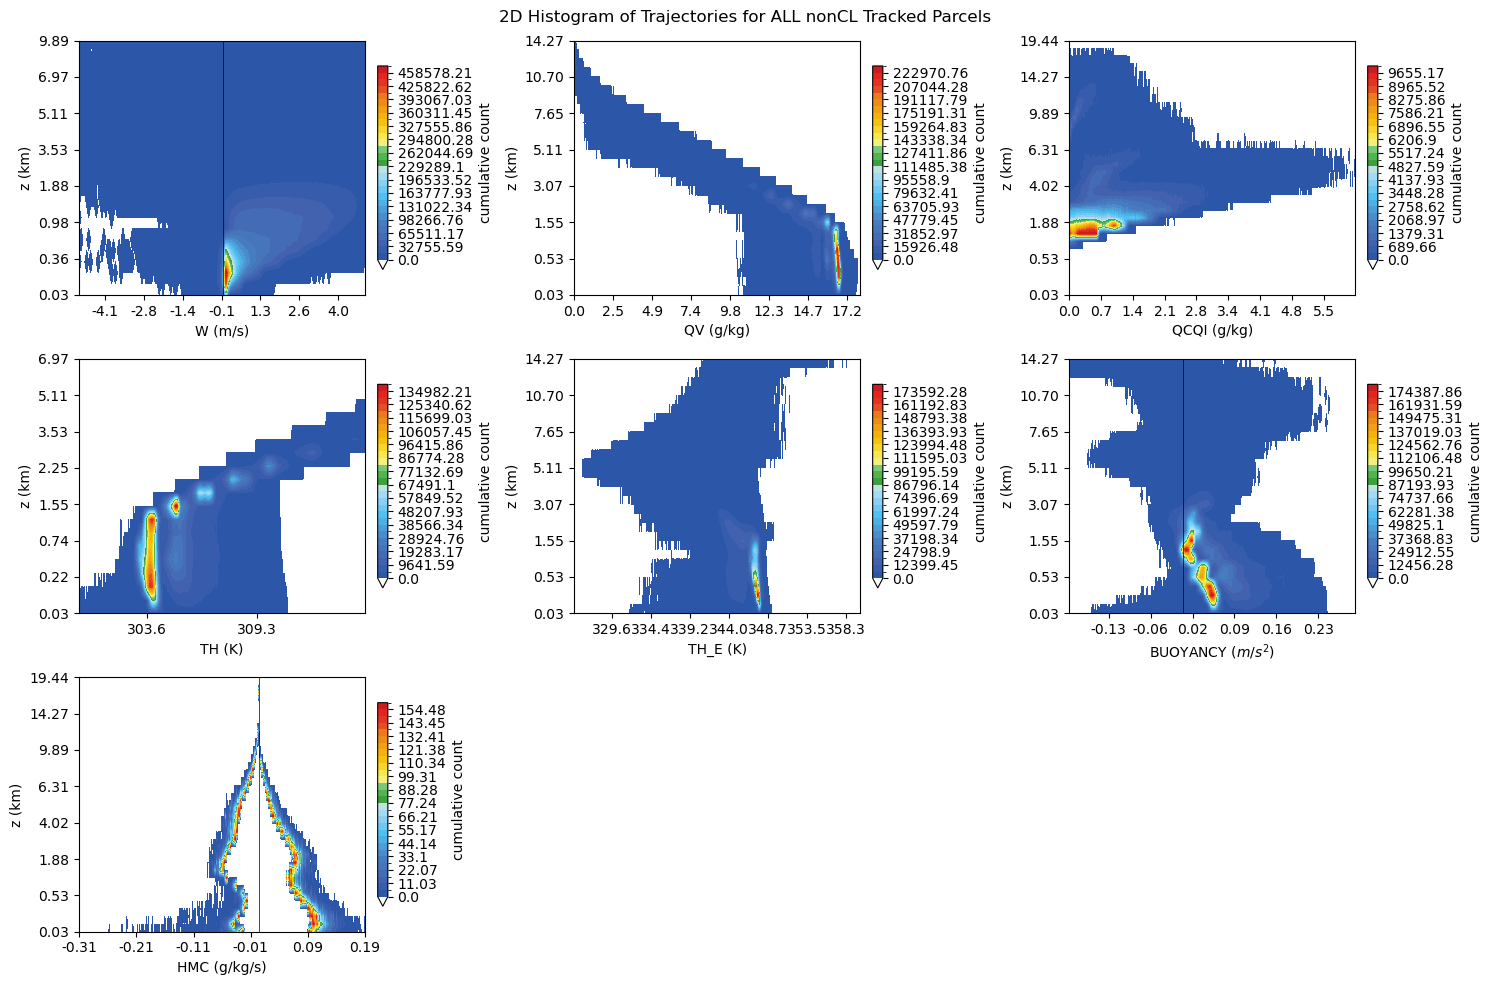

In [175]:
#PLOTTING ALL VARIABLES SINGLE PLOT
#####################################

type2='CL'
type2='nonCL'
# type2='SBZ'
# type2='nonSBZ'
# type2='ColdPool'

type='ALL'
# type='SHALLOW'
# type='DEEP'

#####################################
AllPlots(type,type2)

In [ ]:
######################################################################

In [ ]:
#PLOTTING EVERY PLOT
#####################################
for type in ['ALL','SHALLOW','DEEP']:
    for type2 in ['CL','nonCL','SBZ','nonSBZ','ColdPool']:
        AllPlots(type,type2)